In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_stata('data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)
df

,v1,v2,Version,doi,v3,v4,V4a,v5,v6,v7,...,v72,v73,v74,v75,v76,v77,v78,v79,v80,V81
0,2391,1.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,2,2,5,5,0,1.640,0,3,0.000
1,2391,2.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,2,99,...,1,2,4,5,5,0,1.670,0,3,0.000
2,2391,3.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,0.650,0,3,0.000
3,2391,4.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,98,99,...,99,0,4,5,5,0,0.820,0,3,0.000
4,2391,5.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,1.670,0,3,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,2391,501626.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,10,0,4,3,0,4,0.383,0,50,0.383
1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,6,2,3,1,0,1,0.596,0,50,0.596
1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,22,...,10,0,4,13,0,5,1.969,0,50,0.954
1046817,2391,501629.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,4,99,23,...,10,0,4,14,0,4,1.038,0,50,0.503


In [3]:
partie_codes = {
    1  : 'CDU',
    2  : 'SPD',
    3  : 'FDP',
    4  : 'Gruene',
    8  : 'NPD',
    49 : 'AfD',
    97 : 'undecided'
}

votes_partie_df = df[['v4', 'v6']]
votes_partie_df.loc[:,'v6'] = votes_partie_df['v6'].apply(lambda x: partie_codes[x] if x in partie_codes.keys() else x)

total_votes_per_year = pd.DataFrame(votes_partie_df.groupby(by=['v4']).size())

total_votes_per_year = total_votes_per_year.reset_index()
votes_partie_df = pd.DataFrame(votes_partie_df.groupby(by=['v4','v6']).size())

votes_partie_df = votes_partie_df.reset_index()
#votes_partie_df[0] = votes_partie_df[0] / total_votes_per_year[0]
votes_partie_df = votes_partie_df.set_index('v4')
total_votes_per_year = total_votes_per_year.set_index('v4')
votes_partie_df['total'] =  total_votes_per_year
votes_partie_df['vote percentage'] = votes_partie_df[0] / votes_partie_df['total']
votes_partie_df

/tmp/ipykernel_9310/767208015.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['CDU' 'SPD' 'CDU' ... 38 99 'CDU']' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  votes_partie_df.loc[:,'v6'] = votes_partie_df['v6'].apply(lambda x: partie_codes[x] if x in partie_codes.keys() else x)


,v6,0,total,vote percentage
v4,,,,
1977,11,52,10151,0.005123
1977,98,1157,10151,0.113979
1977,99,643,10151,0.063344
1977,CDU,3810,10151,0.375332
1977,FDP,822,10151,0.080977
...,...,...,...,...
2022,CDU,5677,26615,0.213301
2022,FDP,1478,26615,0.055533
2022,Gruene,5713,26615,0.214653


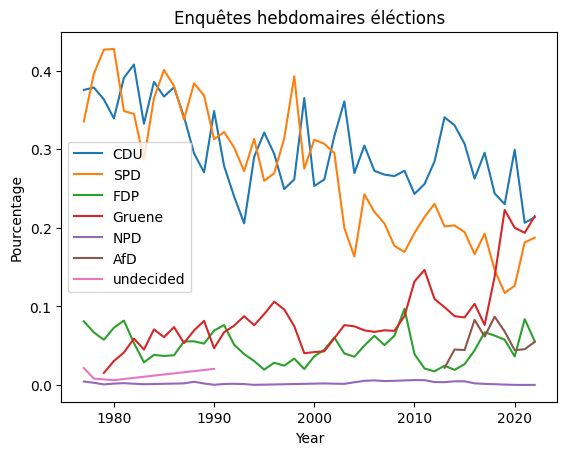

In [4]:
votes_partie_df = votes_partie_df.query(f'v6 in {list(partie_codes.values())}' )
for partie in partie_codes.values():
    votes_partie_df[votes_partie_df['v6'] == partie]['vote percentage'].plot(label=partie)
plt.xlabel('Year')
plt.ylabel('Pourcentage')
plt.title('Enquêtes hebdomaires éléctions')
plt.legend()
plt.show()

## France  

In [ ]:
xdf = pd.read_stata('data/barometre_confiance_14_cum.dta',convert_categoricals=True)
df

,id,vague,pays,poids1,poids2,poids3,poids4,poids5,poids6,Q0v14_FR,...,r29it,r30,r30uk,r30de,r30it,po1,rs40,qf,device,age
0,_vdza44Z4eHA_RYs4-AZpQ,14.0,France,0.877850,0.311474,0.967353,0.878120,0.405069,0.519687,avoir confiance en soi,...,NaN,"De temps en temps, aux grandes fêtes, pour les...",NaN,NaN,NaN,Non,De 2.300 Euros à moins de 3.000 Euros,Oui,Navigateur récent,37.0
1,-FCOtznB0w-zpT1XcR5k2w,14.0,France,1.544212,0.963014,0.907377,1.576755,0.899060,0.914173,,...,NaN,NaN,NaN,NaN,NaN,NaN,De 2.000 Euros à moins de 2.300 Euros,Oui,Sur android,35.0
2,-ivldxHChL8ebaF0hzI00g,14.0,France,0.907280,1.368906,0.907377,0.983270,0.429495,0.537110,Fiable,...,NaN,Jamais,NaN,NaN,NaN,Non,De 3.000 Euros à moins de 4.500 Euros,Oui,Sur android,42.0
3,-psK8s51KsdD-k5jOCmqvg,14.0,France,0.705615,1.074242,0.858303,0.700934,0.522148,0.417724,etre sure de quelqu un,...,NaN,"De temps en temps, aux grandes fêtes, pour les...",NaN,NaN,NaN,Oui,De 1.000 Euros à moins de 1.200 Euros,Oui,Navigateur récent,34.0
4,0o6U1F04OrieLfvqHVkH8w,14.0,France,0.812085,1.098135,1.083207,0.816584,0.388341,0.480754,"complicité, pouvoir se confier sans avoir peur...",...,NaN,"De temps en temps, aux grandes fêtes, pour les...",NaN,NaN,NaN,Non,Moins de 1.000 Euros,Oui,Navigateur récent,43.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8086,c4evxzcydnit,14.0,Italie,0.976102,0.000000,NaN,NaN,NaN,1.059449,,...,Cattolico,NaN,NaN,NaN,"Di tanto in tanto, in occasione delle principa...",Non,6 000 Euros et plus,Oui,Navigateur récent,38.0
8087,c4fhlfr6dnit,14.0,Italie,0.496231,0.000000,NaN,NaN,NaN,0.538603,,...,Cattolico,NaN,NaN,NaN,"Di tanto in tanto, in occasione delle principa...",Non,De 2.300 Euros à moins de 3.000 Euros,Oui,Sur android,71.0
8088,c4fkws3idnit,14.0,Italie,1.104406,0.000000,NaN,NaN,NaN,1.198708,,...,Cattolico,NaN,NaN,NaN,Mai,Non,De 1.200 Euros à moins de 1 400 Euros,Oui,Navigateur récent,35.0
8089,c4fl9405dnit,14.0,Italie,1.211200,0.000000,NaN,NaN,NaN,1.314622,,...,Nessuna religione,NaN,NaN,NaN,"Di tanto in tanto, in occasione delle principa...",Non,De 1.700 Euros à moins de 2.000 Euros,Oui,Sur android,54.0


In [12]:
df = pd.read_spss('data/barometre_confiance_8.spss',convert_categoricals=True)
df

,id,vague,Poids,Poids1,Poids2,Poids3,Poids4,Poids5,q1a,q1b,...,v1t18,v1t19,v1t110,v1t111,v1t112,v1t1recf,qf,temps,Insee,ville
0,0a23809,8.0,0.888755,0.969096,0.161714,0.948329,0.155129,0.729314,Cité,Pas cité,...,NaN,NaN,La liste du Parti Socialiste et alliés conduit...,NaN,NaN,Parti Socialiste,Oui,1844.0,59265,Gommegnies
1,0a27001,8.0,0.832873,0.707406,0.496372,0.657528,0.467142,0.511109,Pas cité,Pas cité,...,NaN,NaN,NaN,NaN,NaN,Front de Gauche,Oui,1736.0,76351,Le Havre
2,0a29737,8.0,1.060218,1.137289,1.630527,1.125280,1.604955,1.772379,Pas cité,Cité,...,NaN,NaN,NaN,NaN,NaN,Front National,Oui,1695.0,91386,Mennecy
3,0i21935,8.0,1.156248,1.019255,0.264023,1.174703,0.331346,1.361993,Pas cité,Pas cité,...,NaN,NaN,NaN,NaN,NaN,Front National,Oui,12759.0,30341,Vauvert
4,0i22473,8.0,1.192955,1.279700,0.194333,1.223715,0.181688,1.243303,Pas cité,Cité,...,NaN,NaN,NaN,NaN,NaN,Abstention,Oui,2803.0,12090,Druelle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2039,yup9j229max,8.0,1.344543,1.450526,1.266511,1.431748,1.229144,0.860153,Pas cité,Pas cité,...,NaN,NaN,NaN,NaN,NaN,Parti Socialiste,Oui,772048.0,31163,Drémil-Lafage
2040,yyy4cfe73d3r,8.0,0.966990,0.847848,5.142884,0.799737,5.043643,0.834659,Cité,Cité,...,NaN,La liste du Front National conduite par Philip...,NaN,NaN,NaN,Front National,Oui,1330.0,37261,Tours
2041,z64455uymaxi,8.0,0.820762,0.874510,5.251816,0.886659,5.480582,0.682033,Pas cité,Cité,...,NaN,NaN,NaN,NaN,NaN,Republicains UDI Modem,Oui,1465.0,56078,Guidel
2042,z8uf3f22b1uf,8.0,1.532605,1.666325,0.622425,1.688358,0.633656,0.944021,Cité,Pas cité,...,NaN,NaN,NaN,NaN,NaN,Republicains UDI Modem,Oui,2251.0,,


In [ ]:
folder_path = 'data'
dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith('barometre'):
        file_path = os.path.join(folder_path, filename)
        print(filename)
        if filename.endswith('.dta'):
            df = pd.read_stata(file_path,convert_categoricals= False)
        elif filename.endswith('.sav') or filename.endswith('.spss'):
            df = pd.read_spss(file_path)
        else:
            continue  # Ignorer les fichiers avec des extensions non prises en charge
        dfs.append(df)

# Afficher le nombre de DataFrames importés
print(f'Nombre de DataFrames importés : {len(dfs)}')


barometre_confiance_9_cum.dta
barometre_confiance_15_cum.sav
barometre_confiance_14_cum.dta
barometre_confiance_13.sav
barometre_confiance_6.spss
barometre_confiance_5.spss
barometre_confiance_12_cum.dta
barometre_confiance_7.sav
barometre_confiance_8.spss
barometre_confiance_11_cum.dta
barometre_confiance_6b.sav
barometre_confiance_9.dta
barometre_confiance_10.spss
Nombre de DataFrames importés : 13
